In [3]:
%pip install img2table -q


[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# get the PubTables-1M paper, source of original Table Transformer (TATR)
!mkdir ./samples
!wget -O ./samples/tatr.pdf -q https://arxiv.org/pdf/2110.00061
!wget -O ./samples/attention.pdf -q https://arxiv.org/pdf/1706.03762
!wget -O ./samples/nmr.pdf -q http://ccc.chem.pitt.edu/wipf/Web/NMR_Impurities.pdf

In [4]:
from img2table.document import PDF

pdf = PDF("samples/tatr.pdf",
          # pages=[0, 2],
          detect_rotation=False,
          pdf_text_extraction=True)

In [5]:
from img2table.ocr import TesseractOCR
from img2table.document import Image

# Instantiation of OCR
ocr = TesseractOCR(n_threads=1, lang="eng")

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX512BW
 Found AVX512F
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [6]:
# Table extraction
import time
start = time.time()
extracted_tables = pdf.extract_tables(ocr=ocr,
                                      implicit_rows=True,
                                      borderless_tables=True,
                                      min_confidence=50)
end = time.time()
print(f"Took {end - start:.3f}s")

Took 52.574s


,0,1,2,3,4,5,6,7
0,Dataset,Input\nModality,# Tables,Cell\nTopology,Cell\nContent,Cell\nLocation,Row & Column\nLocation,Canonical\nStructure
1,TableBank [9],Image,145K,✓,,,,
2,SciTSR [3],PDF∗,15K,✓,✓,,,
3,"PubTabNet [22,23]",Image,510K‡,✓,✓,✓†,,
4,FinTabNet [22],PDF∗,113K,✓,✓,✓†,,
5,PubTables-1M (ours),PDF∗,948K,✓,✓,✓,✓,✓


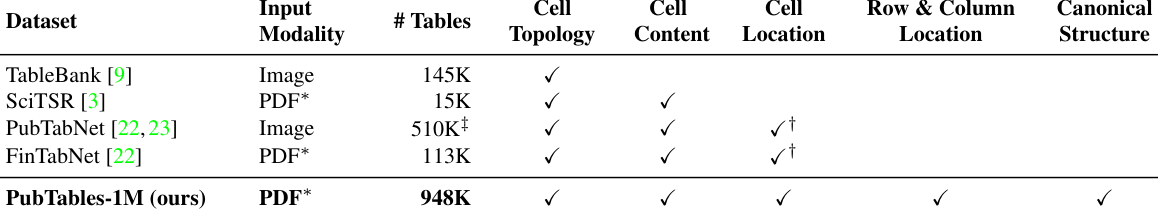

,0,1,2,3,4,5
0,Dataset,Total Tables,Total Tables,,Tables with an oversegmented PRH,Tables with an oversegmented PRH
1,Dataset,Investigated†,with a PRH∗,Total,% (of total with a PRH),% (of total investigated)
2,SciTSR,"10,431",342,54,15.79%,0.52%
3,PubTabNet,"422,491","100,159","58,747",58.65%,13.90%
4,FinTabNet,"70,028","25,637","25,348",98.87%,36.20%
5,PubTables-1M (ours),"761,262","153,705",0,0%,0%


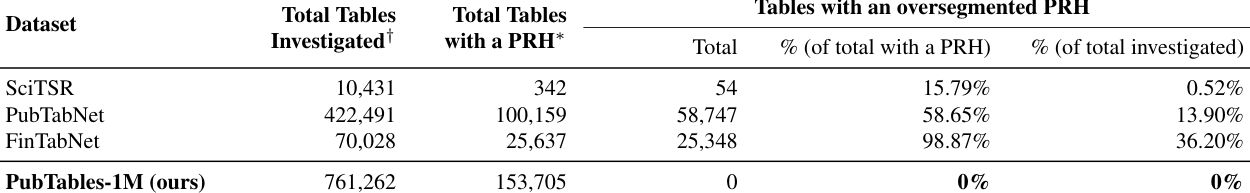

,0,1,2,3,4,5
0,Task,Model,AP,AP50,AP75,AR
1,TD,Faster R-CNN,0.825,0.985,0.927,0.866
2,,DETR,0.966,0.995,0.988,0.981
3,TSR + FA,Faster R-CNN,0.722,0.815,0.785,0.762
4,,DETR,0.912,0.971,0.948,0.942


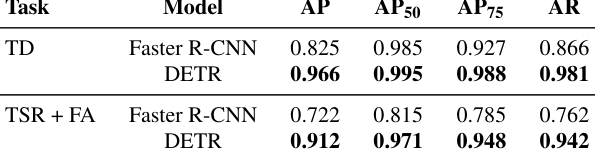

,0,1,2,3,4,5,6,7
0,Test Data,Model,Table Category\nAccCont,Table Category\nAccCont,GriTSTop,GriTSCont,GriTSLoc,AdjCont
1,Non-Canonical,DETR-NC,Simple,0.8678,0.9872,0.9859,0.9821,0.9801
2,,,Complex,0.5360,0.9600,0.9618,0.9444,0.9505
3,,,All,0.7336,0.9762,0.9761,0.9668,0.9681
4,Canonical,DETR-NC,Simple,0.9349,0.9933,0.9920,0.9900,0.9865
5,,,Complex,0.2712,0.9257,0.9290,0.9044,0.9162
6,,,All,0.5851,0.9576,0.9588,0.9449,0.9494
7,,Faster R-CNN,Simple,0.0867,0.8682,0.8571,0.6869,0.8024
8,,,Complex,0.1193,0.8556,0.8507,0.7518,0.7734
9,,,All,0.1039,0.8616,0.8538,0.7211,0.7871


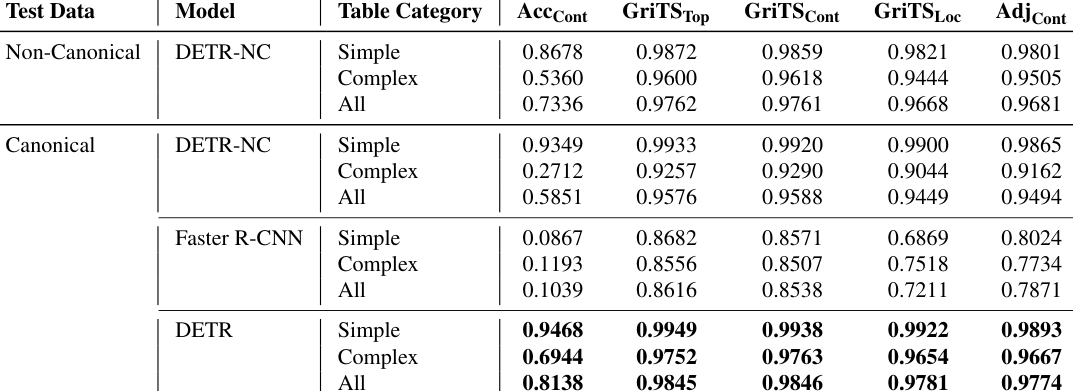

In [11]:
from PIL import Image
import numpy as np

def get_cropped_table(table, page, pdf):
    """
    Extrai uma imagem recortada da tabela do PDF.
    
    Args:
        table: Objeto tabela com as coordenadas bbox
        page: Número da página
        pdf: Objeto PDF
    
    Returns:
        Image: Imagem recortada da tabela
    """
    bbox = table.bbox
    # Converte a região da tabela em um array numpy
    table_array = np.array(pdf.images[page][bbox.y1:bbox.y2, bbox.x1:bbox.x2])
    # Converte o array numpy em uma imagem PIL
    return Image.fromarray(table_array.astype('uint8'))

# No seu código principal:
for page, tables in extracted_tables.items():
    for idx, table in enumerate(tables):
        display_html(table.html_repr(title=f"Page {page + 1} - Extracted table n°{idx + 1}"), raw=True)
        try:
            table_image = get_cropped_table(table, page, pdf)
            display(table_image)
        except Exception as e:
            print(f"Erro ao processar tabela {idx + 1} da página {page + 1}: {str(e)}")

In [10]:
# Display extracted tables
from IPython.display import display_html, display

for page, tables in extracted_tables.items():
    for idx, table in enumerate(tables):
        display_html(table.html_repr(title=f"Page {page + 1} - Extracted table n°{idx + 1}"), raw=True)
        display(get_cropped_table(table, page, pdf))

,0,1,2,3,4,5,6,7
0,Dataset,Input\nModality,# Tables,Cell\nTopology,Cell\nContent,Cell\nLocation,Row & Column\nLocation,Canonical\nStructure
1,TableBank [9],Image,145K,✓,,,,
2,SciTSR [3],PDF∗,15K,✓,✓,,,
3,"PubTabNet [22,23]",Image,510K‡,✓,✓,✓†,,
4,FinTabNet [22],PDF∗,113K,✓,✓,✓†,,
5,PubTables-1M (ours),PDF∗,948K,✓,✓,✓,✓,✓


AttributeError: type object 'Image' has no attribute 'fromarray'